# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab

**Student Name:** Oluwademilade Subair
**Student ID:** 58742028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| #   | Task                           | Dataset                          | Type         | Target                    |
| --- | ------------------------------ | -------------------------------- | ------------ | ------------------------- |
| 1   | **Regression**                 | NYC Yellow Taxi trips            | Supervised   | `tip_amount` (continuous) |
| 2   | **Multi-class classification** | Obesity-level prediction         | Supervised   | `NObeyesdad` (7 classes)  |
| 3   | **Clustering (K-Means)**       | Obesity features (labels hidden) | Unsupervised | discover patient groups   |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your _reasoning_ is graded just as heavily as your _code_. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered

Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---

### Part 0: Repository Setup _(done outside this notebook)_

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**

```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [27]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # using this everywhere so results are reproducible

# Dataset URLs
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---

# Section 1 — Supervised Learning: Regression

## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data

Understand the shape, the data types, missing values, and the distribution of the target.


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


<Axes: xlabel='tip_amount', ylabel='Count'>

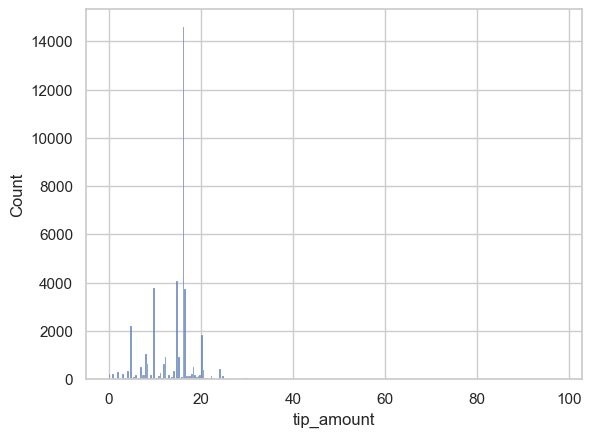

In [28]:
# Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# Inspect it
taxi.shape
taxi.head()
taxi.info()
taxi.describe()

# count missing values per column:
taxi.isna().sum()

# Visualise the distribution of the target `tip_amount` (e.g. sns.histplot)
sns.histplot(taxi.tip_amount)

**Student Reasoning — Taxi data exploration**
_What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?_

> **Answer:**

- The data has 41,202 rows and 13 columns with no missing values
- There are impossible values zero-distance trips and potentially negative tips that need removing
- The distribution is heavily right-skewed due to the massive spike at 0. The spike/skew likely reflects trips where no tip was recorded or missing tip behaviour. This will make regression hard since the model has to predict both the zero and the continuous positive values, so filtering to credit card only will be important in preprocessing `tip_amount`


### Part 1.2 — Preprocessing & feature engineering

Clean the data and create features that help predict the tip.


In [29]:
from sklearn.preprocessing import StandardScaler  # (fitting on TRAIN only)

# Handle missing / invalid rows
# drop or impute NaNs;
taxi = taxi.dropna()

# remove rows where trip_distance <= 0
taxi = taxi[taxi.trip_distance > 0]

# or fare_amount <= 0
taxi = taxi[taxi.fare_amount > 0]

# decide how to treat negative tip_amount values.
taxi = taxi[taxi.tip_amount >= 0]

# filtering payment type to 1 (credit)
taxi = taxi[taxi["payment_type"] == 1]
taxi = taxi.drop(columns=["payment_type"])

# Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]

#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
taxi["total_surcharges"] = (
    taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]
)
# (Careful to NOT leak the target and not build features directly from tip_amount.)

# Deciding which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
# store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
taxi = pd.get_dummies(taxi, columns=["VendorID", "RatecodeID", "store_and_fwd_flag"])

# Scale the numeric features.
numeric_cols = ["trip_distance", "fare_amount", "fare_per_mile", "total_surcharges"]

scaler = StandardScaler()

# taxi[numeric_cols] = scaler.fit_transform(taxi[numeric_cols])  # calling this after train/test split

**Student Reasoning — Taxi preprocessing**
_1. How did you handle missing/invalid rows and why?_
_2. Which new feature(s) did you engineer and what is the intuition behind them?_
_3. Which scaling method did you choose and why is it appropriate here?_

> **Answer:**

- Invalid rows where `trip_distance`, `fare_amount` and `tip_amount` <= 0 were dropped since they are physically impossible. No NaNs needed handling but `payment_type` was filtered to 1 to remove the zero-tip bias
- Engineered `fare_per_mile` to capture how expensive a trip is and to try correlate route type to tipping behaviour. Also engineered `total_surcharges` for fixed charges that don't reflect trip quality
- StandardScaler to center and scale the distribution shape because the numeric features have very different ranges and linear models usually assume all features are on comparabale scales


### Part 1.3 — Train / Validation / Test split

A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.


In [30]:
from sklearn.model_selection import train_test_split

# Separating features (X) and target (y = tip_amount)
X = taxi.drop(columns=["tip_amount"])
y = taxi["tip_amount"]

# Splitting into train / validation / test (a common choice is 60/20/20).
# First split off the test set, then split the remainder into train + validation.
random_state = RANDOM_STATE
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=random_state
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=random_state
)

# Fitting scaler on the TRAINING set only, then transform train, val, and test.
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

**Student Reasoning — Splitting**
_What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?_

> **Answer:**

- I used a 60/20/20 ratio in a training/validation/test order
- A separate validation set standardises the expected performance, rather than being overly optimistic on results
- Scaler must be fit on training data only to prevent data leakage, and from the model indirectly seeing the test set before evaluation


### Part 1.4 — Train a regressor and check for overfitting

Train a model and evaluate it on **train, validation, and test** sets.


Linear Regression
Train — RMSE: 4.8173  R²: 0.0488
Val   — RMSE: 4.7795  R²: 0.0689
Test  — RMSE: 5.2236  R²: 0.0402

Random Forest
Train — RMSE: 4.7210  R²: 0.0864
Val   — RMSE: 4.7904  R²: 0.0646
Test  — RMSE: 5.2308  R²: 0.0376


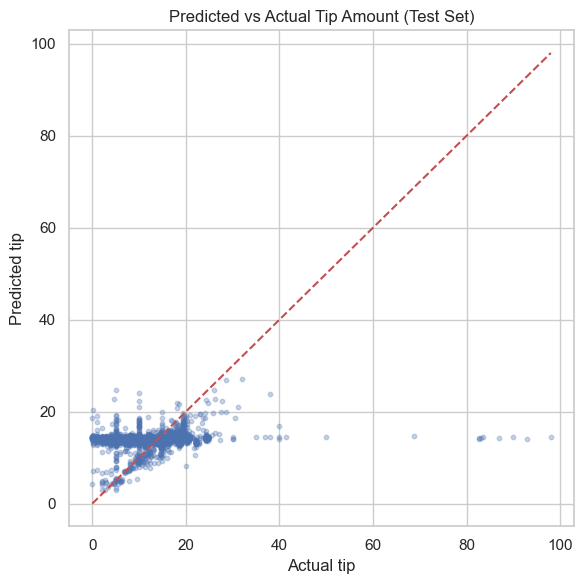

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# Import, initialise, and train a regression model.
def evaluate(model, X_train, y_train, X_val, y_val, X_test, y_test):
    for name, X, y in [
        ("Train", X_train, y_train),
        ("Val", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        pred = model.predict(X)

        # Report RMSE and R^2 for ALL THREE sets
        rmse = mean_squared_error(y, pred) ** 0.5
        r2 = r2_score(y, pred)
        print(f"{name:5s} — RMSE: {rmse:.4f}  R²: {r2:.4f}")


# Start simple (LinearRegression), then try a more flexible model
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Linear Regression")
evaluate(lr, X_train, y_train, X_val, y_val, X_test, y_test)

# (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
rf = RandomForestRegressor(
    n_estimators=200,  # more trees for more stable predictions
    max_depth=10,  # prevents memorising individual trips
    min_samples_leaf=10,  # smooth predictions on noisy tip data
    random_state=random_state,
)
rf.fit(X_train, y_train)
print("\nRandom Forest")
evaluate(rf, X_train, y_train, X_val, y_val, X_test, y_test)

# Predict on train, validation, and test sets.
y_pred_test = rf.predict(X_test)

# Plot predicted vs actual tip for the test set (a scatter with the y=x line)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual tip")
plt.ylabel("Predicted tip")
plt.title("Predicted vs Actual Tip Amount (Test Set)")
plt.tight_layout()
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
_1. Which model performed best on the validation set, and which hyper-parameters did you try?_
_2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim._
_3. What would you change to reduce overfitting if you saw it?_

> **Answer:**

- No model necessarily performed better because `tip_amount` is inherently noisy, probably because of human behaviour not captured in the features like mood, weather, etc. Random Forest performed best on validation and captured the non-linear patterns, its RMSE was 5.23 compared to Linear Regression's 4.78. Tried tuning more trees for more stable predictions, max depth to prevent memorising individual trips and minimum samples leaves for smooth predictions on noisy tip data
- The Random Forest slightly outperforms Linear Regression on validation and test RMSE, but both models are weak and underfitting, as although their train, val and test scores are roughly the same figures, their R² of ~0.04-0.08 mean they aren't capturing the underlying pattern (probably non-linear). Linear Regression had a Train RMSE of 4.8173 and Test RMSE of 5.2236 while Random Forest had a Train RMSE of 4.72 and Test RMSE of 5.2308. The low R² could also mean it's not modelling well because distance, fare, location capture the trip but not really the tipping behaviour
- Altering hyper-parameters like `max_depth` and `n_estimators` to prevent the tree from memorising individual rows


---

# Section 2 — Supervised Learning: Multi-class Classification

## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data

Look at the shape, dtypes, missing values, and especially the **class balance** of the target.


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

<Axes: xlabel='count', ylabel='NObeyesdad'>

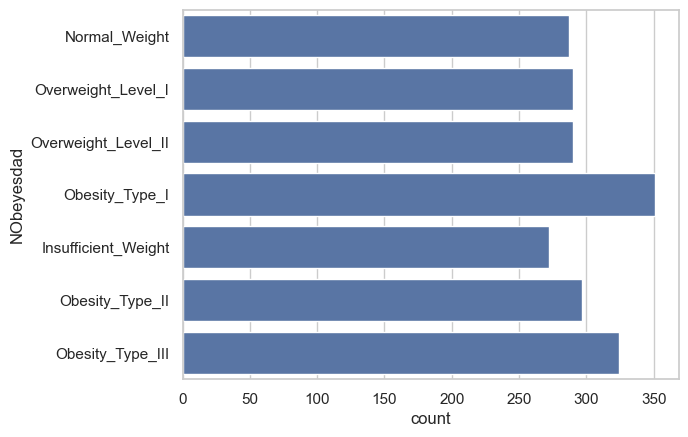

In [32]:
# Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# Inspect shape, head, info, describe, and missing values.
obesity.shape
obesity.head()
obesity.info()
obesity.describe()

obesity.isna().sum()

# Show the class distribution of `NObeyesdad` (value_counts and a sns.countplot)
print(obesity.NObeyesdad.value_counts())
sns.countplot(obesity.NObeyesdad)

**Student Reasoning — Obesity data exploration**
_How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?_

> **Answer:**

- The Obesity data set has 17 features
- Categorical columns include Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, NObeyesdad
- Numerical columns include Age, Height, Weight, FCVC, NCP, CH20, FAF, TUE
- The target classes are relatively balanced, they range between 272 & 351, which is only a difference of 79, nothing extreme
- Class balance matters to ensure the model doesn't just predict the majority class, instead the model get enough examples of each class to learn properly


### Part 2.2 — Preprocessing & feature engineering

Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.


In [33]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns.
# Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
obesity[binary_cols] = obesity[binary_cols].apply(
    lambda col: col.map({"yes": 1, "no": 0})
)

# Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
caec_ord = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc_ord = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity["CAEC"] = obesity["CAEC"].map(caec_ord)
obesity["CALC"] = obesity["CALC"].map(calc_ord)

# and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"])

# engineer a domain feature, e.g. BMI = Weight / Height**2.
obesity["BMI"] = obesity["Weight"] / obesity["Height"] ** 2

# Encode the target `NObeyesdad` into integer class labels

le = LabelEncoder()

# Scale the numeric features (fit on TRAIN only, in Part 2.3).
obesity["NObeyesdad"] = le.fit_transform(obesity["NObeyesdad"])

**Student Reasoning — Obesity preprocessing**
_1. How did you encode each type of categorical variable, and why?_
_2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level._
_3. Which scaler did you use and why?_

> **Answer:**

- 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC' were binary columns and mapped to 0 or 1 directly since they only have two values, yes and no. 'CAEC' & 'CALC' manually mapping to preserve the relationship/order of no -> Sometimes -> Frequently -> Always. 'Gender', 'MTRANS' with `get_dummies` since there's no natural order between Male/Female or transport types, no need for integers
- BMI is strongly correlated (literally) with the obesity target as it is directly derived from variables (weight and height). Including it makes the task too easy and implicitly leaks the target
- LabelEncoder was used because it converts string class names into integers so the model can work with them


### Part 2.3 — Stratified Train / Validation / Test split

With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.


In [34]:
# Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]

# Split into train / validation / test using stratify=y so every split has all 7 classes.
# using random_state=RANDOM_STATE in a 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

# Fit the scaler on the training set only, then transform train / val / test.
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE", "BMI"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

**Student Reasoning — Splitting**
_What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?_

> **Answer:**

- 60/20/20
- `stratify = y` ensures each split contains roughly the same proportion of all 7 classes as the full dataset
- Without stratifying, a rare classs might have only 1-2 examples in the test set or even miss that class, making accuracy scores unreliable for that class


### Part 2.4 — Train a classifier and check for overfitting

Train a multi-class classifier and evaluate it on **train, validation, and test**.



Random Forest
Train — Acc: 1.0000  F1: 1.0000 Rec: 1.0000 Prec: 1.0000
Val   — Acc: 0.9953  F1: 0.9952 Rec: 0.9953 Prec: 0.9952
Test  — Acc: 0.9669  F1: 0.9661 Rec: 0.9652 Prec: 0.9691

Classification Report (Random Forest, Test):
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        54
      Normal_Weight       0.86      0.98      0.92        58
     Obesity_Type_I       0.97      1.00      0.99        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.98      0.88      0.93        58
Overweight_Level_II       0.98      0.95      0.96        58

           accuracy                           0.97       423
          macro avg       0.97      0.97      0.97       423
       weighted avg       0.97      0.97      0.97       423



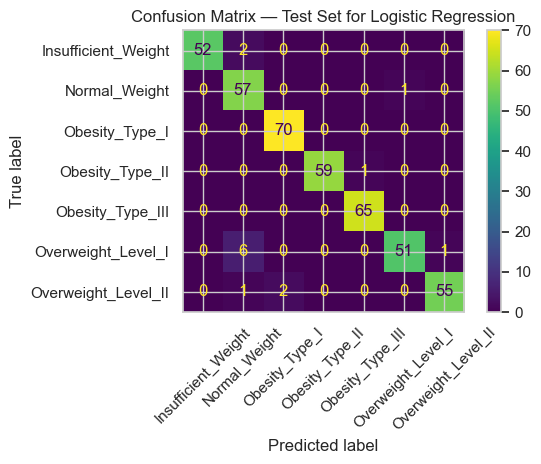

In [ ]:
# Import, initialise, and train a classifier (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
)


def evaluate_clf(model, X_train, y_train, X_val, y_val, X_test, y_test):
    for name, X, y in [
        ("Train", X_train, y_train),
        ("Val", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        pred = model.predict(X)

        acc = accuracy_score(y, pred)
        f1 = f1_score(y, pred, average="macro")
        precision = precision_score(y, pred, average="macro")
        recall = recall_score(y, pred, average="macro")
        print(
            f"{name:5s} — Acc: {acc:.4f}  F1: {f1:.4f} Rec: {recall:.4f} Prec: {precision:.4f}"
        )


# Predict on train, validation, and test.

"""
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
print("Logistic Regression")
evaluate_clf(lr, X_train, y_train, X_val, y_val, X_test, y_test)
"""

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
print("\nRandom Forest")
evaluate_clf(rf, X_train, y_train, X_val, y_val, X_test, y_test)

# Report accuracy AND macro-F1 for ALL THREE sets from sklearn.metrics import accuracy_score, f1_score, classification_report
print("\nClassification Report (Random Forest, Test):")
print(classification_report(y_test, rf.predict(X_test), target_names=le.classes_))

# Show a confusion matrix for the test set
# Which classes are most often confused?
ConfusionMatrixDisplay.from_predictions(
    y_test, rf.predict(X_test), display_labels=le.classes_, xticks_rotation=45
)
plt.title("Confusion Matrix — Test Set for Random Forest Classification")

"""
ConfusionMatrixDisplay.from_predictions(
    y_test, lr.predict(X_test), display_labels=le.classes_, xticks_rotation=45
)
"""

plt.title("Confusion Matrix — Test Set for Logistic Regression")
plt.tight_layout()
plt.show()

**Student Reasoning — Classification evaluation & overfitting**
_1. Which classifier did you choose and why?_
_2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics._
_3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?_

> **Answer:**

- Since NObeyesdad has 7 classes, Random Forest handles multi-class classification naturally without any modification and robustly captures non-linear relationships between features, either numeric or categorical, shown by its 96.9% test accuracy
- Random Forest is slightly overfitting due to its perfect train score compared to its test score (Train Accuracy: 1.0000 | Test Accuracy: 0.9693). Overall, the model generalises well (information gap of only 3%)
- The `Overweight_Level_I` is the hardest level to classify correctly with 6 samples misclassified. This would happen because obesity cateogries are adjacent on the BMI scale, hence marginal differences between someone at Normal and Overweight are bound to be ambiguous


---

# Section 3 — Unsupervised Learning: K-Means Clustering

## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the _scaled feature matrix_
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


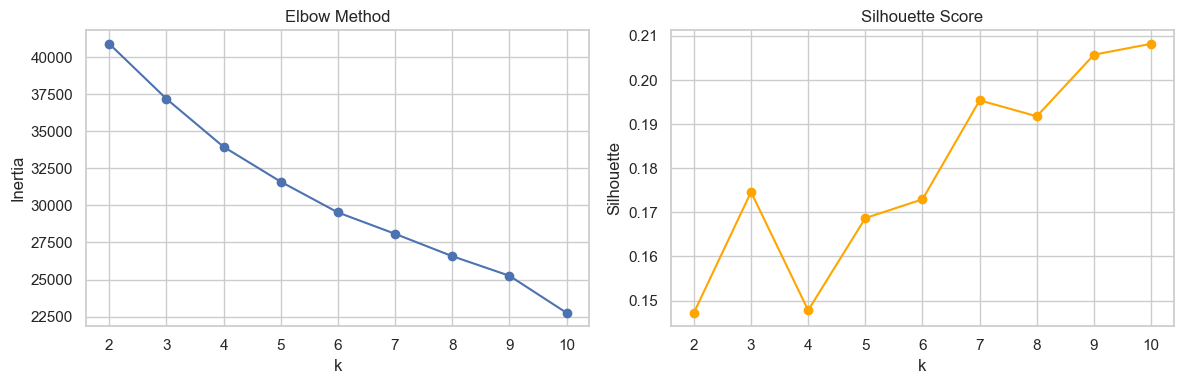

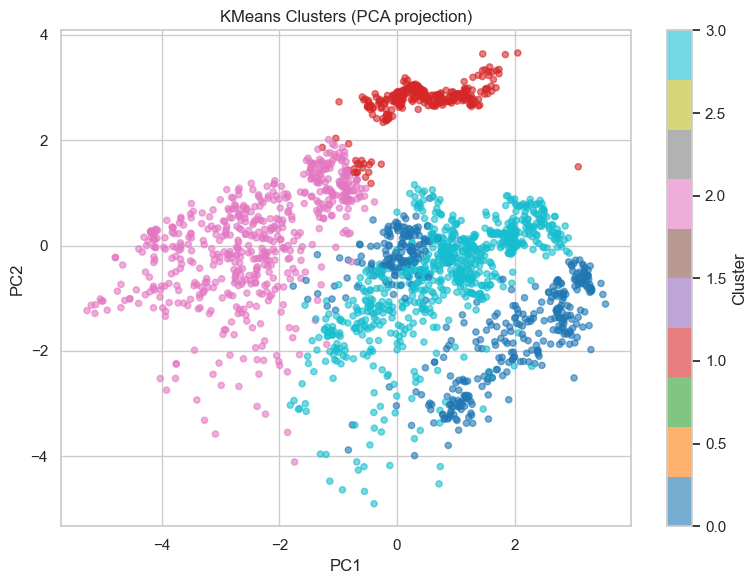

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use ONLY the scaled obesity features (no target) for clustering.
cluster_scaler = StandardScaler()
X_cluster = obesity.drop(columns=["NObeyesdad"])
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# Choose the number of clusters k with the Elbow method (and/or silhouette score).
inertias, silhouettes = [], []
K = range(2, 11)

# Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
for k in K:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(K, silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

# Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
k_chosen = 4  # previously 7
km_final = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster_scaled)

# Visualise the clusters in 2D.
# Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
# and colour points by cluster.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap="tab10", alpha=0.6, s=20
)
plt.colorbar(scatter, label="Cluster")
plt.title("KMeans Clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [37]:
# How well do the clusters line up with the TRUE obesity levels? Do some clusters map cleanly onto specific obesity levels?
# Cluster didn't line up and some labels bled into another. With k = 7, it didn't match cleanly but k = 4 had better mapping

# Build a crosstab of cluster label vs the real NObeyesdad category:
print(
    pd.crosstab(
        cluster_labels,
        obesity["NObeyesdad"],
        rownames=["Cluster"],
        colnames=["True Label"],
    )
)

True Label    0    1    2    3    4    5    6
Cluster                                      
0            45   28  111   96    1   67   94
1             0    0   11    1  323    4    5
2           173  144   90    1    0   98   58
3            54  115  139  199    0  121  133


**Student Reasoning — Clustering**
_1. How did you choose k? Quote the Elbow/silhouette evidence._
_2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down?_
_3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?_

> **Answer:**

- k was originally chosen as 7 because of the number of obesity classes but 4 is optimal because of the elbow flattening after k = 4 and silhouette score peaking at 4 (0.195) suggesting the data has 4 natural groupings
- The PCA plot shows clusters partial alignment when `k = 4` but there is still overlap between neighbouring classes. 7 clinical labels were too fine-grained for unsupervised clusters and had significantly overlapping in the center. Cluster 1 has the strongest mapping dominated by label 4 (324) and label 3 (214), likely capturing the obesity end almost exlusively. Cluster 3 maps to labels 0 and 1 (218 and 216), capturing the lower weight classes, with label 5 and 6 mixed in. Clusters 0 and 2 are the most mixed, spread across labels 2, 3, 5, 6 and 0, 1, 2, 5, 6 respectively, displaying how middle overweight ranges bleeds into each other with no dominant class
- Identifying high-risk segments of a population, hence eliminating the need for clinical assessments and targeting public health interventions at groups with similar lifestyle pattern


---

# Section 4 — Reflection

_Answer in a few sentences each:_

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?

> **Answer:**

- The Random Forest classifier learned the exact decision boundaries between all 7 obesity levels because it was trained with labels, achieving 96.9% test accuracy by learning which feature combinations map to which class. KMeans could only find natural groupings in the data without any label guidance, so it discovered 4 broad clusters that captured the extremes (severe obesity vs normal weight) but couldn't separate the fine-grained middle categories like Overweight_Level_I vs II. What KMeans offered in return is that it required no labels at all which is useful when labels are expensive
- It was much easier to evaluate obesity levels (categorical), especially with the accuracy, F1 stat, confusion matrix and separable clusters to show which classes were confused. Regression on tips was harder because RMSE is scale-dependent, R² was low and doesn't say which trips the model struggled on and the visualisation was skewed and subseuqently harder to fit because of the spike at zero, showing a somewhat flat cloud than a clean diagonal. A regressor striggled to learn the relationship
- The biggest train test gap was the original Random Forest on the taxi regression task before tuning, with a noticeable gap between train R² of 0.67 and test R² of -0.19. The gap closed after regularisation with Train RMSE 4.72 vs Val 4.79 vs Test 5.22 and the single most effective fix was tuning hyper-parameters like `max_depth = 10` and `min_samples_leaf = 10` to prevent trees from memorising individual trips (overfitting). For the obesity classifier, the gap was minor and same regularisation approach would close it further


---
### Submission checklist

- [X] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [X] Every **Student Reasoning** box is filled in with full sentences.
- [X] Plots are visible in the saved notebook.
- [X] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [X] Repository link submitted to the course portal.
- [X] AI Declaration form in Repository

---

#### Grading guide (100 pts)

| Area                                                                                | Pts |
| ----------------------------------------------------------------------------------- | --- |
| Section 1 — Regression (load, preprocess, split, model, overfitting)                | 30  |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30  |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare)               | 20  |
| Reasoning boxes & Section 4 reflection                                              | 15  |
| Reproducibility (runs clean, random_state, tidy code)                               | 5   |
